# MITGCM Regional Kinetic Energy  Analysis 

**Purpose**: Code for computing the MKE and EKE from MITgcm output. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from scipy.ndimage import uniform_filter1d
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from filtering import lanczos_lowpass_filter, butter_lowpass_filter

Set data analysis parameters

In [3]:
# Set processing parameters
option_plot          = 0         # Specifies if supplementary plots are plotted
option_depth         = 9         # Specifies the depth level in meter at which the decorrelation data is computed
option_energy        = 'FKE'     # Specifies which component of the kinetic energy will be computed
option_filter        = 'boxcar'  # Specifies which filtering approach to take. Options include 'butter', 'Lanczos'

# Set time and space parameters
T_cut        = 15                            # Spcifies the cutoff for filtering. Units: days
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/supplementary_figs/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'
PATH_CCE = ROOT + "AirSeaCoupling"
PATH_calCOFI = ROOT + 'AirSeaCoupling/data/calCOFI/'

# Set plotting parameters 
fontsize = 25

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
filename = PATH + "mitgcm_intermediate_data_vel_hrly_map_depth_" + str(option_depth) + "m.nc"
nc = Dataset(filename, 'r')

# Extract data variables
depth = nc.variables['Depth'][:]
lon = nc.variables['lon'][:]
lat = nc.variables['lat'][:]
time =  num2date(nc.variables['time'][:], nc.variables['time'].units)

u = nc.variables['u'][:]
v = nc.variables['v'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Read in bathymetry data

In [5]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Load CCE processed data

In [6]:
# Set start and end times for CCE1 and 2
st_cce1_ctd      = datetime(2016, 1, 1, 0, 0, 0)       # Specifies the start time of the event period 
ed_cce1_ctd      = datetime(2017, 12, 31, 23, 59, 59)  # Specifies the end time of the event period       

st_cce2_ctd      = datetime(2020, 1, 1, 0, 0, 0)       
ed_cce2_ctd      = datetime(2021, 12, 31, 23, 59, 59)        

# Set the file name and read in the data file
filename_CCE1_ctd  = PATH_CCE + "/data/CCE/CCE1/CTD/CCE1_CTD_" + str(st_cce1_ctd.year) + str(st_cce1_ctd.month) + str(st_cce1_ctd.day) +  "-" + str(ed_cce1_ctd.year) + str(ed_cce1_ctd.month) + str(ed_cce1_ctd.day) + "_intermediate_gridded_data.nc"
filename_CCE2_ctd  = PATH_CCE + "/data/CCE/CCE2/CTD/CCE2_CTD_" + str(st_cce2_ctd.year) + str(st_cce2_ctd.month) + str(st_cce2_ctd.day) +  "-" + str(ed_cce2_ctd.year) + str(ed_cce2_ctd.month) + str(ed_cce2_ctd.day) + "_intermediate_gridded_data.nc"

#--- CCE 1 ---# 
nc_CCE1_ctd  = Dataset(filename_CCE1_ctd, 'r')

# Extract data variables
lon1             = nc_CCE1_ctd.variables['LON'][:]
lat1             = nc_CCE1_ctd.variables['LAT'][:]

#--- CCE 2 ---# 
nc_CCE2_ctd  = Dataset(filename_CCE2_ctd, 'r')

# Extract data variables
lon2             = nc_CCE2_ctd.variables['LON'][:]
lat2             = nc_CCE2_ctd.variables['LAT'][:]

#--- CCE 3 ---# 
lon3 = -120.53825701527784 % 360
lat3 = 34.44825228022894

Read in CalCOFI stations

In [7]:
# Load CalCOFI csv file 
filename = PATH_calCOFI + "CalCOFIStationOrder.csv"
calCOFI_data = np.genfromtxt(
    filename,
    delimiter=",",
    skip_header=1,
    usecols=(1, 3, 7, 11),
    invalid_raise=False
)

# Grab stations on line 80.0
calCOFI_line80 = calCOFI_data[calCOFI_data[:, 0] == 80.0] 

# Parse data into separate arrays
calCOFI_stn   = calCOFI_line80[:, 0]
calCOFI_lat   = calCOFI_line80[:, 1]
calCOFI_lon   = calCOFI_line80[:, 2]
calCOFI_depth = calCOFI_line80[:, 3]

Compute the following variables: 

1. **Mean Kinetic Energy** (MKE): Here we define the mean kinetic energy as: 

$$
    \text{MKE}(t,x,y) = \frac{1}{2} \big( u_L^2 + v_L^2\big)
$$

where $(u_L,v_L)$ are the low-pass (90-day) filtered velocities components defined as:

$$
    \textbf{u}_L(t) = \int G_{90}(t-s) \;\textbf{u}(s) ds
$$

where $G_{90}$ is the normalized kernal for the boxed car filter which is given by: 

$$
G_{90}(t-s) =
\begin{cases}
\dfrac{1}{T}, & |t-s|\le \dfrac{T}{2}, \\[6pt]
0, & \text{otherwise},
\end{cases}
\qquad T = 90 ~\text{days}.
$$

MKE is the kinetic energy associated with the large-scale, slowly varying, persistent flow. This includes things like the mean currents (e.g., the California Current, Gulf Stream, or Equatorial Currents) and seasonal cycles.

2. **Eddy Kinetic Energy** (EKE): Here we define the eddy kinetic energy as: 

$$
    \text{EKE}(t,x,y) = \frac{1}{2} \big( u_H^2 + v_H^2\big)
$$

where $(u_H,v_H)$ are the high-pass (fluctuating) components defined as:

$$
    \textbf{u}_H(t) = \textbf{u} - \textbf{u}_L
$$

EKE is the kinetic energy associated with the transient, fluctuating, high-frequency motions.

In [8]:
# Compute low-pass filtered velocities (with respect to time)
if option_filter == 'boxcar': 

    # Set parameters
    dt_hours = (time_dt[1] - time_dt[0]).total_seconds() / 3600  # time step in hours
    window_size = int(T_cut * 24 / dt_hours)                         # number of timesteps in 90 days

    # Filter data 
    u_L = uniform_filter1d(u, size=window_size, axis=0, mode='nearest')
    v_L = uniform_filter1d(v, size=window_size, axis=0, mode='nearest')

elif option_filter == 'Lanczos':

    # Set parameters
    dt = 1.0            # 1 day sampling
    cutoff = 1.0/T_cut  # cutoff frequency in cycles/day
    window = 60         # ~2*T is typical

    # Filter data 
    u_L = lanczos_lowpass_filter(u, cutoff=cutoff, window=window, dt=dt, axis=0)
    v_L = lanczos_lowpass_filter(v, cutoff=cutoff, window=window, dt=dt, axis=0)

elif option_filter == 'butter': 

    # Set parameters
    dt = 1.0            # 1 day sampling
    cutoff = 1.0/T_cut  # cycles per day

    # Filter data
    u_L = butter_lowpass_filter(u, cutoff=cutoff, dt=dt, order=4, axis=0)
    v_L = butter_lowpass_filter(v, cutoff=cutoff, dt=dt, order=4, axis=0)

# Compute high-pass filtered velocities 
u_H = u - u_L
v_H = v - v_L

# Compute components of the kinetic energy 
if option_energy == 'MKE': 

    # Compute Mean Kinetic Energy (MKE)
    MKE = 0.5 * (u_L**2 + v_L**2)

    # Compute time-mean field 
    MKE_mean = np.mean(MKE, axis=0) 
    MKE_var = np.var(MKE, axis=0, ddof=1)

elif option_energy == 'EKE': 

    # Compute Eddy Kinetic Energy (EKE)
    EKE = 0.5 * (u_H**2 + v_H**2)

    # Compute time-mean and variance field 
    EKE_mean = np.mean(EKE, axis=0)
    EKE_var = np.var(EKE, axis=0, ddof=1)

elif option_energy == 'FKE': 

    # Compute Eddy Kinetic Energy (EKE)
    EKE = 0.5 * (u_H**2 + v_H**2)

    # Compute Mean Kinetic Energy (EKE)
    MKE = 0.5 * (u_L**2 + v_L**2)

    # Compute the fraction of the total kinetic energy associated with Eddy kinetic energy
    FKE = EKE/(EKE + MKE)

    # Compute time-mean and variance field 
    FKE_mean = np.ma.mean(FKE, axis=0)
    FKE_var = np.ma.var(FKE, axis=0, ddof=1)

elif option_energy == 'CKE': 

    # Compute the cross-term in the kinetic energy decomposition
    CKE = u_L*u_H + v_L*v_H

    # Compute time-mean field 
    CKE_mean = np.mean(CKE, axis=0)
    CKE_var = np.var(CKE, axis=0, ddof=1)

elif option_energy == 'KE':

    # Compute the total kinetic energy 
    KE = 0.5 * (u**2 + v**2)

    # Compute time-mean field 
    KE_mean = np.mean(KE, axis=0)
    KE_var = np.var(KE, axis=0, ddof=1)

Compute climatology of the kinetic energy field 

In [9]:
# Set data array for computing climatology
if option_energy == 'MKE': 
    data = MKE
elif option_energy == 'EKE':
    data = EKE
elif option_energy == 'FKE':
    data = FKE
elif option_energy == 'CKE':
    data = CKE
elif option_energy == 'KE':
    data = KE

# Initialize arrays 
data_clima_m    = []
data_clima_std  = []
data_clima_var  = []
data_clima_stdm = []
time_month      = []

# Set the month time array
months = np.array([m.month for m in time])

# Loop through months
for m in range(1, 13):

    # Find the indicies for the ith month
    ind = months == m

    # Slice data and time for ith month
    tmp      = data[ind,:,:]
    tmp_time = time_dt[ind] 

    # Compute the monthly mean and standard deviation
    data_clima_m.append(np.mean(tmp, axis=0))
    data_clima_std.append(np.std(tmp, axis=0, ddof=1))
    data_clima_var.append(np.var(tmp, axis=0, ddof=1))

    # Compute the standard error of the mean (assuming that each data point is an independent observations)
    data_clima_stdm.append(np.std(tmp, axis=0, ddof=1)/np.sqrt(np.count_nonzero(~np.isnan(tmp), axis=0)))

    # Save the month time variable 
    time_month.append(m)

# Convert lists to an array
data_clima_m = np.array(data_clima_m)
data_clima_std = np.array(data_clima_std)
data_clima_var = np.array(data_clima_var)
data_clima_stdm = np.array(data_clima_stdm)
time_month = np.array(time_month)

Set plotting parameters

In [10]:
# Set plotting parameters 
fontsize = 25

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

# Set plotting parameters for cartopy functions
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123
lon_max = -120
lat_min = 33
lat_max = 35
cmap = cmo.thermal

if option_energy == 'MKE': 
    data_mean = MKE_mean
    data_var  = MKE_var 
    label_mean = r'MKE (m$^2$/s$^2$)'
    label_var  = r'$\sigma_{MKE}^2$ (m$^2$/s$^2$)'
    levels_mean = np.logspace(np.log10(1e-3), np.log10(2e-2), num=35) #np.arange(0,0.03 + 0.001,0.001)  
    levels_var  = np.logspace(np.log10(1e-6), np.log10(1e-3), num=35)
    norm_mean = mcolors.LogNorm(vmin=1e-3, vmax=2e-2)
    norm_var = mcolors.LogNorm(vmin=1e-6, vmax=1e-3)
elif option_energy == 'EKE':
    data_mean = EKE_mean
    data_var  = EKE_var
    label_mean = r'EKE (m$^2$/s$^2$)'
    label_var  = r'$\sigma_{EKE}^2$ (m$^2$/s$^2$)'
    levels_mean = np.logspace(np.log10(3e-3), np.log10(5e-2), num=35)  #np.arange(0,0.03 + 0.001,0.001) 
    levels_var  = np.logspace(np.log10(3e-6), np.log10(4e-2), num=35) #np.arange(0,0.0005,0.000005)
    norm_mean = mcolors.LogNorm(vmin=3e-3, vmax=5e-2)
    norm_var = mcolors.LogNorm(vmin=3e-6, vmax=4e-2)
elif option_energy == 'FKE':
    data_mean = FKE_mean
    data_var  = FKE_var
    label_mean = r'FKE (\%)'
    label_var  = r'$\sigma_{FKE}^2 ($\%$)$'
    levels_mean = np.arange(0.3,0.8+0.02,0.02)*100
    levels_var = np.arange(0.04,0.11+0.0025,0.0025)*100
elif option_energy == 'CKE':
    data_mean = CKE_mean
    data_var  = CKE_var
    label_mean = r'CKE (m$^2$/s$^2$)'
    label_var  = r'$\sigma_{CKE}^2$ (m$^2$/s$^2$)'
    levels_mean = np.arange(0,0.005,0.0001)
    levels_var  = np.arange(0,2,0.05)
elif option_energy == 'KE':
    data_mean = KE_mean
    data_var  = KE_var
    label_mean = r'KE (m$^2$/s$^2$)'
    label_var  = r'$\sigma_{KE}^2$ (m$^2$/s$^2$)'
    levels_mean = np.arange(0,0.06,0.001)
    levels_var  = np.arange(0,2,0.05)

Plot time mean of component of kinetic energy 

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)


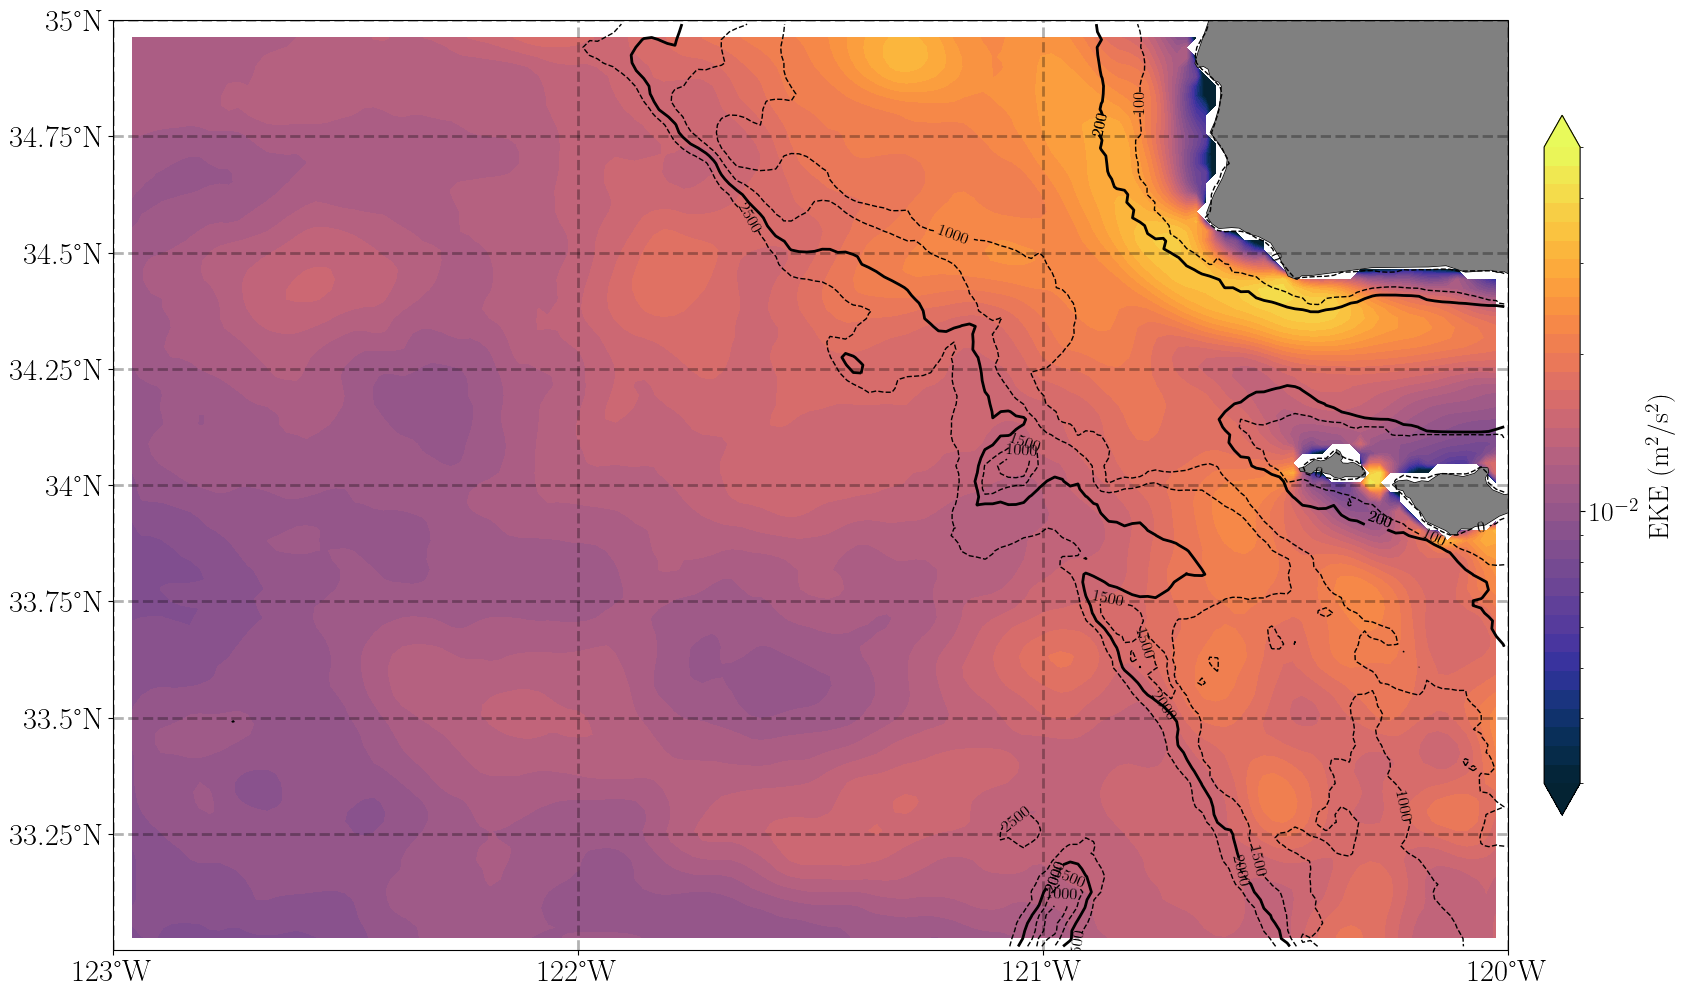

In [23]:
# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
cf = axes.contourf(
    lon, lat, data_mean, levels=levels_mean,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm_mean,  
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
cbar.ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)*0.1))
cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
cbar.set_label(label_mean)

# Show the plot
plt.show()

Plot time variance of component of kinetic energy 

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_68030/3991102273.py:43: UserWarning: Adding colorbar to a different Figure <Figure size 1800x2000 with 2 Axes> than <Figure size 1800x2000 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')


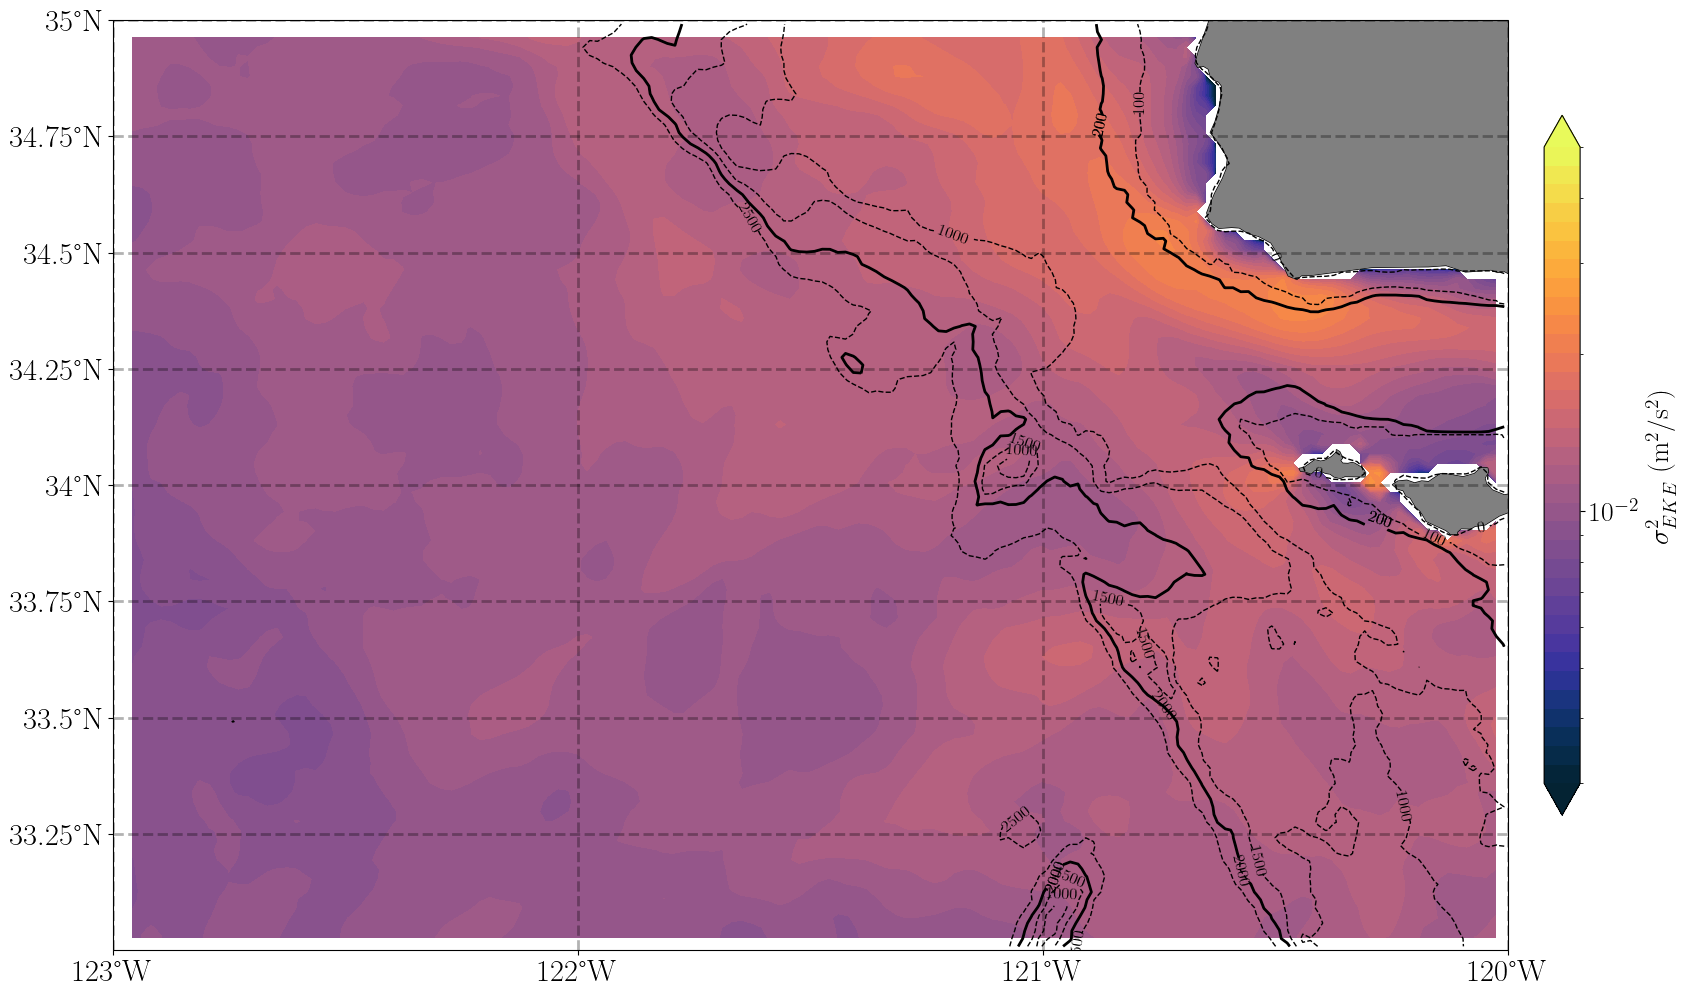

In [24]:
# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
mesh = axes.contourf(
    lon, lat, data_var, levels=levels_var,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    norm=norm_var, 
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
cbar.ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)*0.1))
cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
cbar.set_label(label_var)

# Show the plot
plt.show()

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: Log scale: values of z <= 0 have been masked
  res

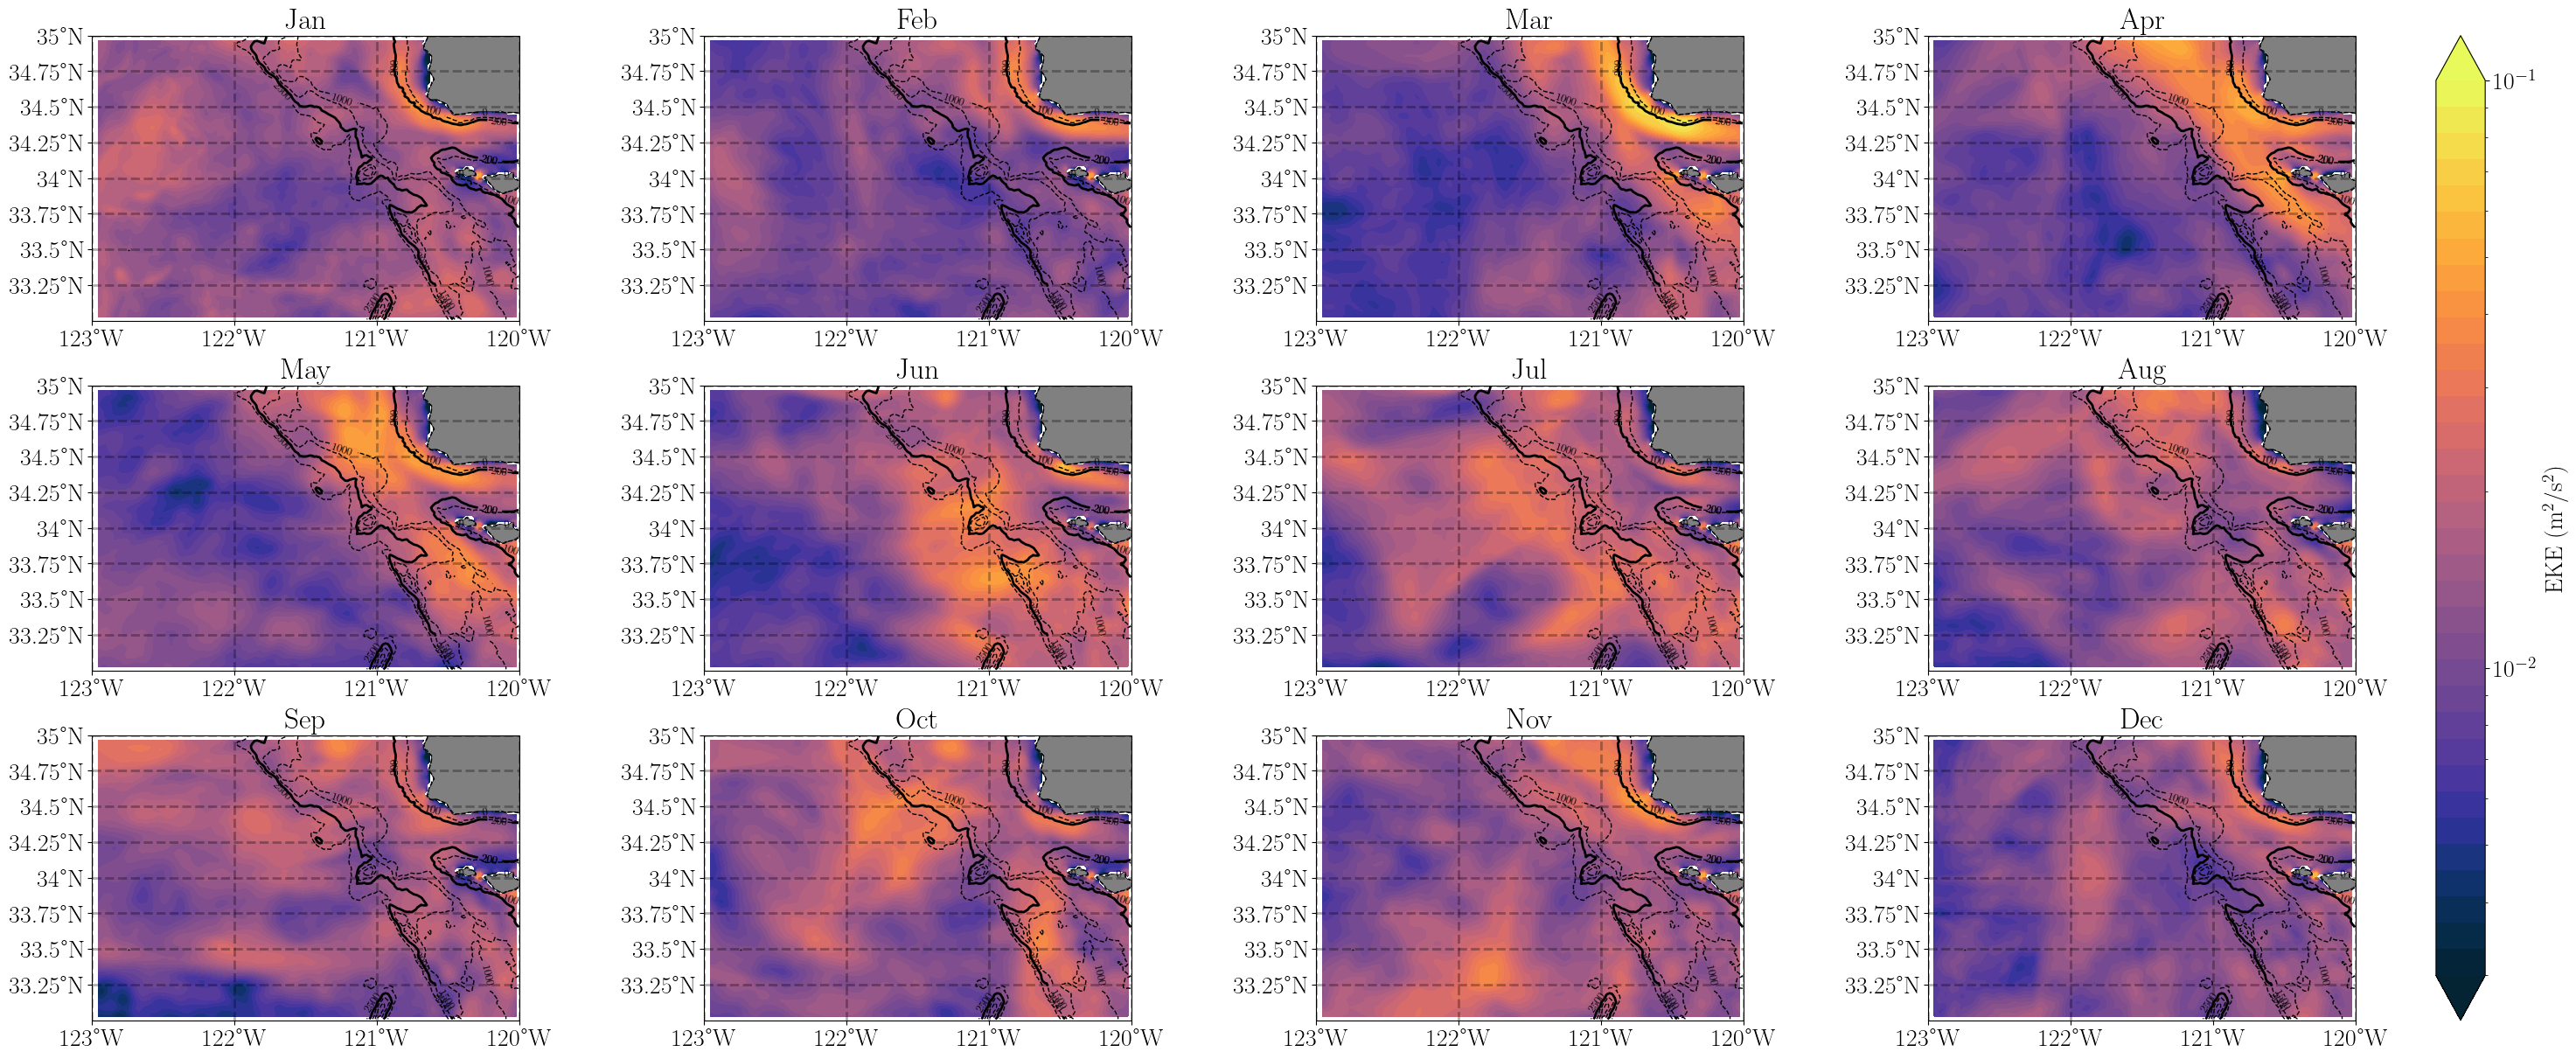

In [27]:
# Set plotting parameters
levels_mean = np.logspace(np.log10(3e-3), np.log10(1e-1), num=35)  
norm_mean = mcolors.LogNorm(vmin=3e-3, vmax=1e-1)

# Create 3x4 subplot grid
fig, axes = plt.subplots(3, 4, figsize=(30,12), constrained_layout=True, subplot_kw={"projection": projection})
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Loop over months
for i in range(12):

    # Set the row and column iteration
    row = i // 4
    col = i % 4

    # Set the axis for the ith plot
    ax = axes[row, col]

    # Set figure axes 
    cart.set_subplots(ax, projection, resolution, lon_min=-123, lon_max=-120, lat_min=33, lat_max=35) 

    # Plot velocity gradient for the ith month
    pcm = ax.contourf(lon, lat, data_clima_m[i], levels=levels_mean, cmap=cmap, norm=norm_mean, extend='both')
    ax.set_title(month_names[i])

    # Plot depth contour lines
    level_innershelf = np.arange(0,300,100)
    levels_midshelf = np.arange(1000,3000,500)
    contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
    contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
    contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
    contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
    plt.clabel(contour1, fontsize=9)
    plt.clabel(contour2, fontsize=9)
    plt.clabel(contour3, fontsize=9)
    plt.clabel(contour4, fontsize=9)

    # Set grid ticks 
    cart.set_grid_ticks(
        ax,
        projection=ccrs.PlateCarree(),
        xticks=xticks,
        yticks=yticks,
        xlabels=True,
        ylabels=True,
        grid=True,
        fontsize=fontsize,
        color="black",
    )

# Add colorbar
cbar = fig.colorbar(pcm, ax=axes, orientation='vertical', fraction=0.025, pad=0.02, extend='both')
cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
cbar.ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)*0.1))
cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
cbar.set_label(label_mean)

# Display figure
plt.show()

Same figures but for FKE

<>:19: SyntaxWarning: invalid escape sequence '\%'
<>:19: SyntaxWarning: invalid escape sequence '\%'
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_74856/3837443639.py:19: SyntaxWarning: invalid escape sequence '\%'
  axes.clabel(ct, fmt=lambda val: f'{val:.0f}$\%$', fontsize=fontsize-5, colors='w')


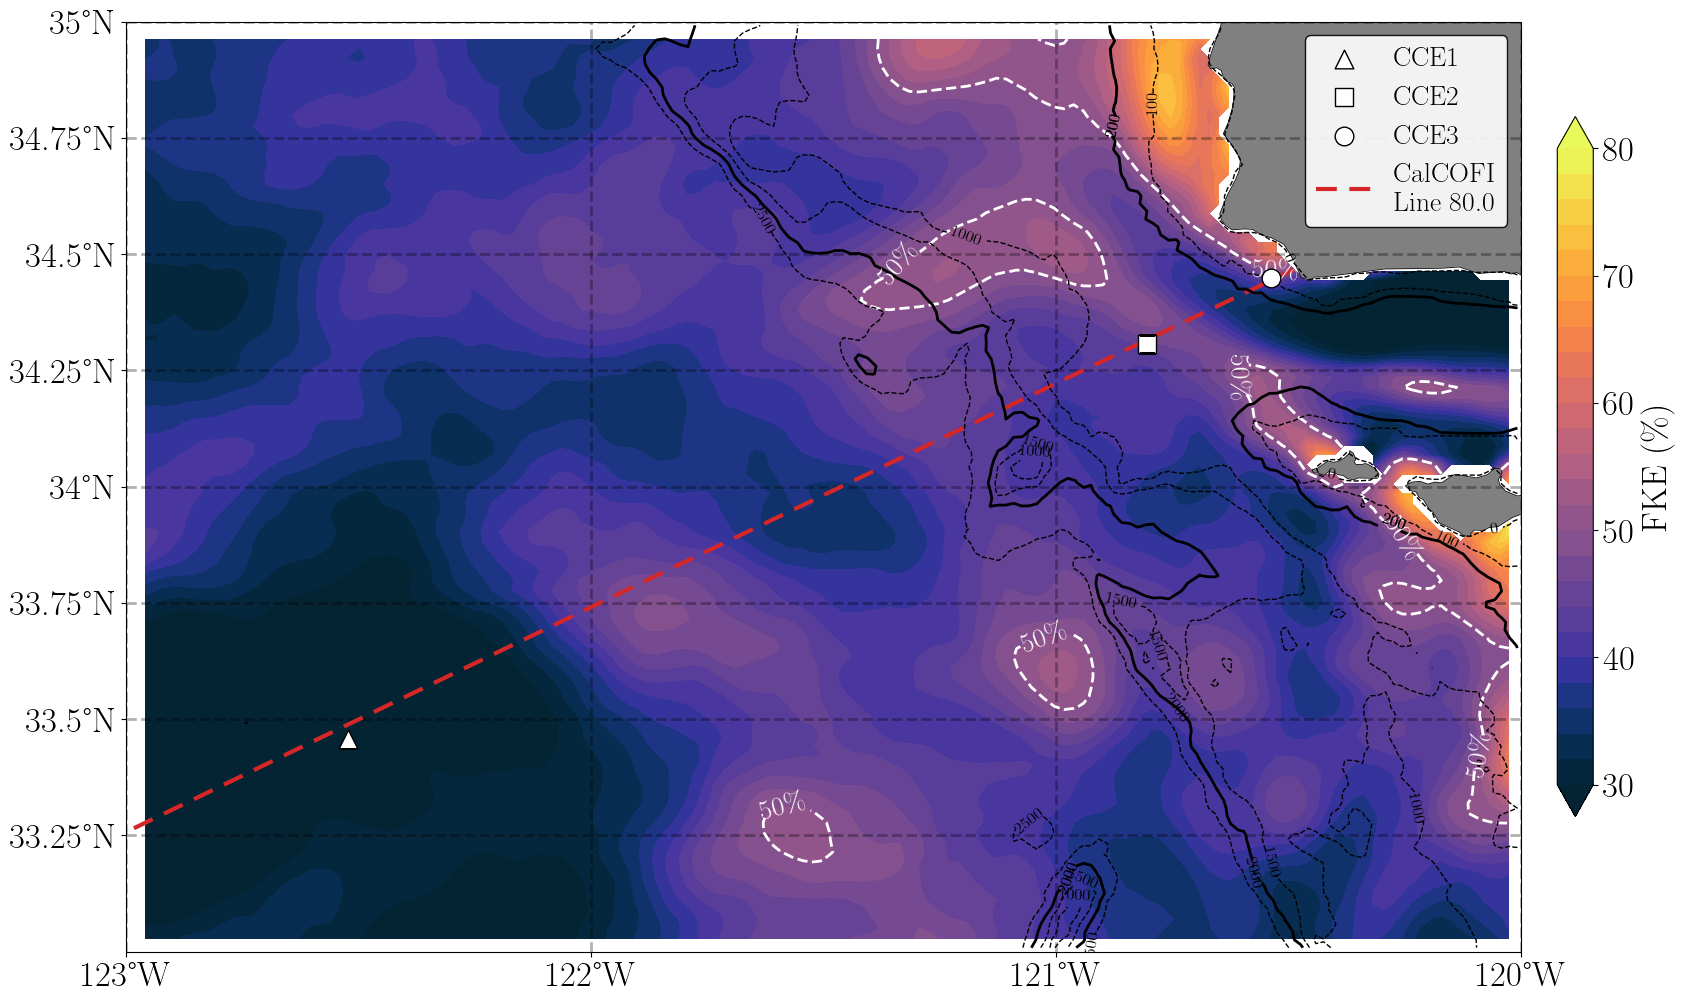

In [11]:
# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
cf = axes.contourf(
    lon, lat, data_mean*100, levels=levels_mean,
    transform=ccrs.PlateCarree(),
    cmap=cmap, 
    extend = 'both'
)

# Plot the 50% contour level
ct = axes.contour(lon, lat, data_mean*100, levels=[50], colors='white', linestyles='--', linewidths=2) 

# Add 50% contour level label
axes.clabel(ct, fmt=lambda val: f'{val:.0f}$\%$', fontsize=fontsize-5, colors='w')

#--- CCE1 ---# 

# Plot the mooring point
axes.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

#--- CCE2 ---# 

# Plot the mooring point
axes.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

#--- CCE3 ---# 

# Plot the mooring point
axes.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
axes.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='tab:red',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree(),
    label='CalCOFI \n Line 80.0'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=fontsize,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label_mean)
cbar.set_ticks(np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8])*100)

# Set legend
axes.legend(
    loc='upper right',
    fontsize=fontsize-5,
    framealpha=0.9,
    edgecolor='black'
)

# Show the plot
plt.show()

# Save with high quality
figName = 'figS09_alt2.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)